# Defringing STIS data

Guide: https://stistools.readthedocs.io/en/latest/defringe_guide.html

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# set up CRDS paths
import os
os.environ['CRDS_PATH']=f"./crds_cache"
os.environ['CRDS_SERVER_URL']=f"https://hst-crds.stsci.edu"
os.environ['oref']=f"{os.environ['CRDS_PATH']}/references/hst/oref/"

In [3]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

import stistools

from coronspec_tools import utils as ctutils

/Users/jaguilar/Projects/miniconda3/envs/stisenv/lib/python3.14/site-packages/stsci/tools/nmpfit.py:8: UserWarning: NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.
  warnings.warn("NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.")
/Users/jaguilar/Projects/miniconda3/envs/stisenv/lib/python3.14/site-packages/stsci/tools/gfit.py:18: UserWarning: GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it.Use astropy.modeling instead.
  warnings.warn("GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it."


The following tasks in the stistools package can be run with TEAL:
   basic2d      calstis     ocrreject     wavecal        x1d          x2d


In [4]:
mpl.rcParams['image.origin'] = 'lower'
mpl.rcParams['image.aspect'] = 'auto'
mpl.rcParams['image.cmap'] = 'plasma'
mpl.rcParams['image.interpolation'] = 'none'

In [5]:
raw_files = sorted(Path("../data/").glob("*raw.fits"))
len(raw_files)

5

We will defringe the first one of these

## Inspect the data

Filename: ../data/of0i01010_raw.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     225   ()      
  1  SCI           1 ImageHDU       121   (1062, 1044)   int16 (rescales to uint16)   
  2  ERR           1 ImageHDU        62   ()      
  3  DQ            1 ImageHDU        45   ()      
  4  SCI           2 ImageHDU       121   (1062, 1044)   int16 (rescales to uint16)   
  5  ERR           2 ImageHDU        62   ()      
  6  DQ            2 ImageHDU        47   ()      


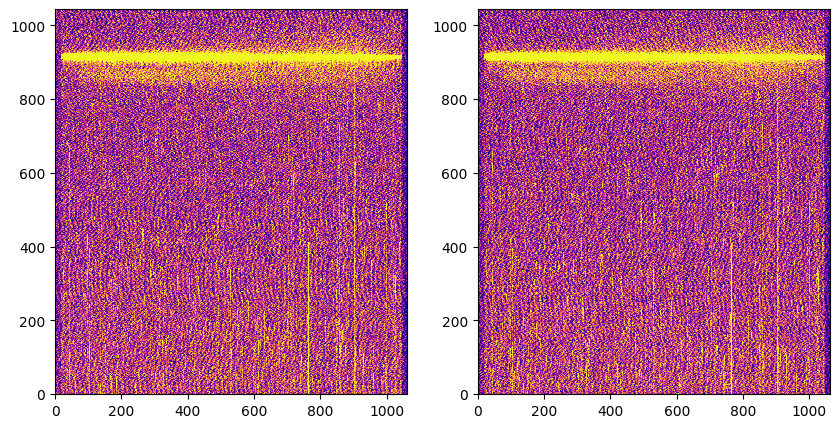

In [6]:
fits.info(raw_files[0])
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))#
ax = axes[0]
img = fits.getdata(raw_files[0], 1)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
ax.imshow(img, vmin=vmin, vmax=vmax)

ax = axes[1]
img = fits.getdata(raw_files[0], 4)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
ax.imshow(img, vmin=vmin, vmax=vmax)

In [7]:
sci_file = raw_files[0]
sci_root = fits.getval(sci_file, 'ROOTNAME', 0)
sci_root

'of0i01010'

In [8]:
data_folder = sci_file.parent
data_folder

PosixPath('../data')

In [9]:
#Confirm that the flat file is indeed the associated fringe flat for odvkl3050
flat_root = fits.getval(sci_file, 'FRNGFLAT', 0).lower()
flat_file = str(sci_file).replace(sci_root, flat_root)
print("Associated Fringe Flat: "+flat_root)
print("Observing Mode: "+fits.getheader(sci_file,0)['OPT_ELEM'])

Associated Fringe Flat: of0i01040
Observing Mode: G750L


In [10]:
output_folder = Path("output/")

In [11]:
stistools.defringe.normspflat?

Signature:
stistools.defringe.normspflat(
    inflat,
    outflat='.',
    do_cal=True,
    biasfile=None,
    darkfile=None,
    pixelflat=None,
    wavecal=None,
)
Docstring:
Normalize STIS CCD fringe flat.

Based on the PyRAF `stsdas.hst_calib.stis.normspflat` task.

Parameters
----------
inflat: str
    Name of input fringe flat
outflat: str
    Name of normalized fringe flat output or directory location.  (Default=".")
do_cal: bool
    Perform bias and dark subtraction and CR rejection?  (Default=True)
biasfile: str or None
    Name of superbias image.  If None, use BIASFILE in main header of the inflat.
darkfile: str or None
    Name of superdark image.  If None, use DARKFILE in main header of the inflat.
pixelflat: str or None
    Name of pixel-to-pixel flat.  If None, use PFLTFILE in main header of the inflat.
wavecal: str or None
    Name of wavecal file [ONLY FOR G750M SPECTRA].  If None, use WAVECAL in main
    header of the inflat.

Returns
-------
outname: str
    Fully qu

In [12]:
nsp_file =  output_folder / f"{flat_root}_nsp.fits"
wav_file = data_folder / f"{sci_root}_wav.fits"
stistools.defringe.normspflat(
    str(flat_file),
    nsp_file, 
    do_cal=True,
    wavecal=None,#wav_file,
)

FileNotFoundError: Cannot access reference file:  /Users/jaguilar/Projects/Research/hst17092-stis_coron/GROSS/dev/crds_cache/references/hst/oref/7bu21310o_bia.fits

In [ ]:
fits.info(nsp_file)

## Clean the CRJ file before defringing

In [15]:
mode = fits.getheader(sci_file,0)['OPT_ELEM']
if mode == "G750L":
    prod_type = "crj"
    # For the G750L grating, the blue end should not be used, so set it to 1
    # in the normalized flat
    with fits.open(nsp_file, mode='update') as hdulist:
        hdulist[1].data[:,:250] = 1
elif mode == "G750M":
    prod_type = "sx2"
input_file = sci_file.parent / sci_file.name.replace("raw",prod_type)
input_file.exists()




False

## Prepare the science file for defringing correction

In [16]:
sci_file

PosixPath('../data/of0i01010_raw.fits')

In [20]:
fits.info("of0i01010_wav.fits")

Filename: of0i01010_wav.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     224   ()      
  1  SCI           1 ImageHDU       120   (1062, 1044)   int16 (rescales to uint16)   
  2  ERR           1 ImageHDU        62   ()      
  3  DQ            1 ImageHDU        45   ()      
  4  SCI           2 ImageHDU       120   (1062, 1044)   int16 (rescales to uint16)   
  5  ERR           2 ImageHDU        62   ()      
  6  DQ            2 ImageHDU        47   ()      


In [21]:
stistools.defringe.prepspec(
    inspec=str(sci_file), 
    outroot=str(output_folder),
)


FileNotFoundError: Cannot access reference file:  /Users/jaguilar/Projects/Research/hst17092-stis_coron/GROSS/dev/crds_cache/references/hst/oref/7bu21313o_drk.fits

In [ ]:
nsp_img = fits.getdata(nsp_file, 1)
vmin, vmax = np.nanquantile(nsp_img, [0.01, 0.99])
plt.imshow(nsp_img, vmin=vmin, vmax=vmax)

In [ ]:
crj_img = fits.getdata(input_file, 1)
vmin, vmax = np.nanquantile(crj_img, [0.01, 0.99])
plt.imshow(crj_img, vmin=vmin, vmax=vmax)

## Clean and defringe the calibrated images

In [ ]:
import gross

In [ ]:
from gross import cleaning_tools as ct

Replace the CRJ data with the cleaned image

In [ ]:
with fits.open(input_file) as hdulist:
    hdnewlist = hdulist.copy()
    ct.clean_bad_pixels(hdnewlist['SCI'].data, std_thresh=10)
    cleaned_input_file = output_folder / input_file.name.replace(prod_type, 'cleaned_'+prod_type)
    hdnewlist.writeto(str(cleaned_input_file), overwrite=True)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))#

img = fits.getdata(input_file)
clean_img = fits.getdata(cleaned_input_file)
vmin, vmax = np.nanquantile(np.stack((img, clean_img)), [0.01, 0.99])


ax = axes[0]
ax.set_title("Before cleaning")
ax.imshow(img, vmin=vmin, vmax=vmax)

ax = axes[1]
ax.set_title("After cleaning")
ax.imshow(clean_img, vmin=vmin, vmax=vmax)

In [ ]:
frr_file = output_folder / f"{flat_root}_frr.fits"
if os.path.isfile(frr_file):
    os.remove(frr_file)
    
stistools.defringe.mkfringeflat(
    str(cleaned_input_file),
    # str(input_file),
    str(nsp_file),
    str(frr_file), 
    beg_shift=-0.5, end_shift=2, shift_step=0.1,
    beg_scale=0.1, end_scale=2, scale_step=0.04,
)

In [ ]:
fits.info(cleaned_input_file)

In [ ]:
drj_file = stistools.defringe.defringe(
    str(cleaned_input_file), 
    str(frr_file),
    overwrite=True
)

In [ ]:
plt.imshow(fits.getdata(frr_file, 0))

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

img = fits.getdata(cleaned_input_file, 1)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
imax = axes[0].imshow(img, vmin=vmin, vmax=vmax )
fig.colorbar(imax,ax=axes[0], orientation='horizontal')
axes[0].set_title("CRJ")

img = fits.getdata(drj_file, 1)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
imax = axes[1].imshow(img, vmin=vmin, vmax=vmax )
fig.colorbar(imax,ax=axes[1], orientation='horizontal')
axes[1].set_title("DRJ")


img = fits.getdata(drj_file, 1) / fits.getdata(cleaned_input_file, 1)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
imax = axes[2].imshow(img, vmin=vmin, vmax=vmax )
fig.colorbar(imax,ax=axes[2], orientation='horizontal')
axes[2].set_title("DRJ / CRJ")

In [ ]:
# cleaned, with fringes
spec_outfile = str(cleaned_input_file).replace("crj", "x1d")
if Path(spec_outfile).exists():
    os.remove(spec_outfile)
stistools.x1d.x1d(str(cleaned_input_file), output=spec_outfile)

# unclean file, with fringes
uspec_outfile = str(output_folder / str(input_file.name).replace("crj", "ux1d"))
if Path(uspec_outfile).exists():
    os.remove(uspec_outfile)
stistools.x1d.x1d(str(input_file), output=uspec_outfile)

# cleaned, no fringes
dspec_outfile = drj_file.replace("drj", "dx1d")
if Path(dspec_outfile).exists():
    os.remove(dspec_outfile)
stistools.x1d.x1d(drj_file, output=dspec_outfile)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
fig.suptitle(sci_file)
img = fits.getdata(cleaned_input_file, 1)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
imax = axes[0].imshow(img, vmin=vmin, vmax=vmax )
fig.colorbar(imax, ax=axes[0], orientation='horizontal')
axes[0].set_title("CRJ")

img = fits.getdata(drj_file, 1)
vmin, vmax = np.nanquantile(img, [0.05, 0.95])
imax = axes[1].imshow(img, vmin=vmin, vmax=vmax )
fig.colorbar(imax, ax=axes[1], orientation='horizontal')
axes[1].set_title("DRJ")

with fits.open(spec_outfile) as x1d:
    axes[2].plot(
        x1d[1].data['WAVELENGTH'][0],
        x1d[1].data['FLUX'][0],
        '-',
        label='Cleaned, with fringes', alpha=0.7
    )  
# with fits.open(uspec_outfile) as ux1d:
#     axes[2].plot(
#         ux1d[1].data['WAVELENGTH'][0],
#         ux1d[1].data['FLUX'][0],
#         '-',
#         label='Not cleaned, with fringes', alpha=0.7
#     )     
with fits.open(dspec_outfile) as dx1d:
    axes[2].plot(
        dx1d[1].data['WAVELENGTH'][0],
        dx1d[1].data['FLUX'][0],
        '-',
        label='Cleaned and defringed', alpha=1, zorder=-1,
    )

axes[2].legend()

In [ ]:
ux1d[1].data